## <p style="text-align: right;"> &#9989; Put your name here</p>

# CMSE 201: Quiz 3 Sec004 Fall 2023

The goal of this quiz is to give you the opportunity to test out more of the skills that you've developed thus far this semester. In particular, you'll reflect on what you know about writing code using Python and showcase some of your more recently acquired programming skills.

**Important note about using online resources**: This exam is "open internet". That means that you can look up documentation, google how to accomplish certain Python tasks, etc. Being able to effectively use the internet for computational modeling and data science is a very important skill, so we want to make sure you have the opportunity to exercise that skill. **However, the use of any person-to-person communication software is absolutely not acceptable.**

**Do your own work.** This quiz is designed to give *you* the opportunity to show the instructor what you can do and you should hold yourself accountable for maintaining a high level of academic integrity. Any violation of academic integrity could result in you receiving a zero on the quiz.

There are a total of <font color="red">**100 POINTS**</font> possible on this quiz and each part of the quiz can be done independently. **If you get stuck _move on to another part of the quiz to earn some points there!_**

---
# Academic integrity statement (10 points)

In the markdown cell below, put your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.

**NOTE: If you use chatGPT, you must copy/paste into a cell in this quiz (1) your prompt, (2) the output from chatGPT, and (3) Write your answer in separate cells.**

<font size=+3>&#9998;</font> *Put your personal academic integrity statement here.*

---

# 1. Let's compare the production of pumpkins around the world and through history! (50 points) 🎃

Halloween has just passed and there were many pumpkins. Pumpkins are such a charismatic squash. You decide you want to analyze pumpkin production around the world and through the years. Using the Food and Agriculture Organization of the United Nations Statistics site ([FAOSTAT](https://www.fao.org/faostat/en/#home)), you download a pumpkin dataset.

The dataset `pumpkins.csv` has the following columns:

`country`: the country of production  
`year`: the year of production  
`tons`: the production value, in tons  

&#9989;&nbsp; **Part 1.1 (10 points)**

Load the `pumpkins.csv` file provided on D2L **using Pandas** and display the first 10 rows.

- 5pts for reading in the file
- 3pts for displaying the dataset
- 2pts for displaying only the first 10 rows

In [2]:
# Let's make sure pandas is imported
import pandas as pd

# Put your code here


In [1]:
### ANSWER ###
import pandas as pd

df = pd.read_csv("pumpkins.csv")
df.head(10)

,country,year,tons
0,Albania,1990,3900.0
1,Albania,1991,3000.0
2,Albania,1992,4600.0
3,Albania,1993,5200.0
4,Albania,1994,5900.0
5,Albania,1995,5800.0
6,Albania,1996,4800.0
7,Albania,1997,6000.0
8,Albania,1998,6000.0
9,Albania,1999,5900.0


&#9989;&nbsp; **Part 1.2 (25 points)**

That's a lot of pumpkins! 🎃🎃🎃

You want to narrow down your analysis to just one country.

Create a mask that filters the data to show only the rows that match the country you wish to analyze further.

**Display that dataframe once you've created it**, to confirm that you did it correctly.

**Note**: if you didn't get the dataset loaded correctly, try your best to write the code that **should** appropriately mask the data for partial credit.

- 10pts for attempting a mask
- 10pts for correctly masking by country
- 5pts for display

In [ ]:
# Put your code here


In [2]:
### ANSWER ###

df_mexico = df[df["country"]=="Mexico"]
df_mexico

,country,year,tons
3468,Mexico,1961,112000.00
3469,Mexico,1962,113000.00
3470,Mexico,1963,114000.00
3471,Mexico,1964,115000.00
3472,Mexico,1965,116000.00
...,...,...,...
3524,Mexico,2017,710632.12
3525,Mexico,2018,776073.32
3526,Mexico,2019,821277.15
3527,Mexico,2020,756780.51


&#9989;&nbsp; **Part 1.3 (15 points)**

Finally, you are curious about the average `tons` produced by the country you chose. **Write some code to calculate and display the mean tons produced for your country** for the `tons` column of your masked dataframe. Finally, in the markdown cell provided, **write out the mean value and your interpretation of this value**.

**Note #1**: there's more than one way you could do this.

**Note #2**: if you didn't get the dataset loaded correctly, try your best to write the code that **should** calculate and display the mean for partial credit. If you weren't able to mask the data, you can either calculate the mean for all the data or again write code as if you had masked the data.

- 5pts for using masked data to calculate the mean
- 5pts for code to calculate the mean
- 2pts for correctly writing out the mean
- 3pts for writing out your interpretation of the mean

In [ ]:
# Put your code here (10 pts)


What is the value of the mean? (2pts)  
<font size=6 color="#009600">&#9998;</font> *Put your answer here*

What is your interpretation of the value of the mean? (3pts)  
<font size=6 color="#009600">&#9998;</font> *Put your answer here*

In [3]:
### ANSWER ###

df_mexico.describe()

,year,tons
count,61.000000,61.000000
mean,1991.000000,356034.574426
std,17.752934,216653.248747
min,1961.000000,106162.000000
25%,1976.000000,125000.000000
50%,1991.000000,308413.000000
75%,2006.000000,525445.000000
max,2021.000000,821277.150000


In [4]:
### ANSWER ###

import numpy as np
np.mean(df_mexico["tons"])

356034.5744262296

---
# 2. Fitting a model to data with `curve_fit` and visualizing the results (40 points)

We live in a time of rising CO2 concentrations which create rising global temperatures. You are interested in modeling future CO2 levels by studying the past and come across the [Keeling curve](https://keelingcurve.ucsd.edu/): CO2 levels are indeed rising, but dip every summer and rise in the winter. The rise in winter is due to decreases in vegetation and increased burning of fossil fuels for heat in northern latitudes.

You come across a dataset from the [Mauna Loa Observatory in Hawaii](https://scrippsco2.ucsd.edu/data/atmospheric_co2/mlo.html). The data provides weekly CO2 levels measured in parts per million from 1958 to 2023.

**There are two columns in the dataset:**

`days`: Starting on `0` (29 March 1958) and running until `23940` (14 October 2023)  

`CO2ppm`: The CO2 concentration measured on that day (in parts per million)  

***READ IN THE DATA BY EXECUTING THE CELL BELOW***

In [4]:
# RUN THIS CELL to make sure you have the dataset loaded

import pandas as pd

df = pd.read_json('{"days":[0,    7,   14,   21,   28,   35,   49,   56,   98,  105,  112,  119,  126,  133,  140,  154,  161,  224,  231,  238,  245,  252,  259,  266,  273,  280,  287,  294,  301,  308,  322,  329,  336,  343,  357,  364,  371,  378,  385,  392,  399,  406,  413,  420,  434,  441,  448,  455,  462,  469,  476,  483,  490,  497,  511,  518,  525,  532,  539,  546,  553,  560,  567,  574,  581,  588,  595,  602,  609,  616,  623,  630,  637,  644,  651,  658,  665,  672,  679,  686,  693,  700,  707,  714,  721,  728,  735,  742,  749,  756,  763,  770,  777,  784,  791,  798,  805,  812,  819,  826,  833,  840,  847,  854,  861,  868,  875,  882,  889,  896,  903,  910,  917,  924,  931,  938,  945,  952,  959,  966,  973,  980,  987,  994, 1001, 1008, 1015, 1022, 1029, 1036, 1043, 1050, 1057, 1064, 1071, 1078, 1085, 1092, 1099, 1106, 1113, 1120, 1127, 1134, 1141, 1148, 1155, 1162, 1169, 1176, 1183, 1190, 1197, 1204, 1211, 1218, 1225, 1232, 1239, 1246, 1253, 1260, 1267, 1274, 1281, 1288, 1295, 1302, 1309, 1316, 1323, 1330, 1337, 1344, 1351, 1358, 1365, 1372, 1379, 1386, 1393, 1400, 1407, 1414, 1421, 1428, 1435, 1442, 1449, 1456, 1463, 1470, 1477, 1484, 1491, 1498, 1505, 1512, 1519, 1526, 1533, 1540, 1547, 1554, 1561, 1568, 1575, 1582, 1589, 1596, 1603, 1631, 1638, 1645, 1652, 1659, 1666, 1673, 1680, 1687, 1694, 1701, 1708, 1715, 1722, 1729, 1743, 1750, 1757, 1764, 1771, 1778, 1792, 1799, 1806, 1813, 1820, 1827, 1834, 1841, 1848, 1855, 1869, 1876, 1883, 1890, 1897, 1904, 1911, 1918, 1925, 1932, 1939, 1946, 1953, 1960, 1967, 1974, 1981, 1988, 1995, 2002, 2009, 2016, 2023, 2030, 2037, 2044, 2051, 2058, 2072, 2079, 2086, 2093, 2100, 2107, 2114, 2121, 2254, 2261, 2282, 2289, 2296, 2303, 2310, 2317, 2331, 2338, 2345, 2352, 2359, 2366, 2373, 2380, 2387, 2394, 2401, 2408, 2415, 2422, 2429, 2436, 2443, 2450, 2457, 2464, 2471, 2478, 2485, 2492, 2499, 2506, 2513, 2520, 2527, 2534, 2541, 2548, 2555, 2562, 2569, 2576, 2583, 2590, 2597, 2604, 2611, 2618, 2625, 2632, 2639, 2646, 2653, 2660, 2667, 2674, 2681, 2688, 2695, 2702, 2709, 2716, 2723, 2730, 2737, 2744, 2751, 2758, 2765, 2772, 2779, 2786, 2793, 2800, 2807, 2814, 2821, 2828, 2835, 2842, 2849, 2856, 2863, 2870, 2877, 2884, 2891, 2898, 2905, 2912, 2919, 2926, 2933, 2940, 2947, 2954, 2961, 2968, 2975, 2982, 2989, 2996, 3003, 3010, 3017, 3024, 3052, 3059, 3066, 3073, 3080, 3087, 3094, 3101, 3108, 3115, 3122, 3129, 3136, 3150, 3157, 3164, 3171, 3178, 3185, 3192, 3199, 3206, 3213, 3234, 3241, 3248, 3255, 3262, 3269, 3276, 3283, 3290, 3297, 3304, 3311, 3318, 3325, 3332, 3339, 3346, 3353, 3360, 3367, 3374, 3381, 3388, 3395, 3402, 3409, 3416, 3423, 3430, 3437, 3444, 3451, 3458, 3465, 3472, 3479, 3486, 3493, 3500, 3507, 3514, 3521, 3528, 3535, 3542, 3549, 3556, 3563, 3570, 3577, 3584, 3591, 3598, 3605, 3612, 3619, 3626, 3633, 3640, 3647, 3654, 3661, 3668, 3675, 3682, 3689, 3696, 3703, 3710, 3717, 3724, 3731, 3738, 3745, 3752, 3759, 3766, 3773, 3780, 3787, 3794, 3801, 3808, 3815, 3822, 3829, 3836, 3843, 3850, 3857, 3864, 3871, 3878, 3885, 3892, 3899, 3906, 3913, 3920, 3927, 3934, 3941, 3948, 3955, 3962, 3969, 3976, 3983, 3990, 3997, 4004, 4011, 4018, 4025, 4032, 4039, 4046, 4053, 4060, 4067, 4074, 4081, 4088, 4095, 4102, 4109, 4116, 4123, 4130, 4137, 4144, 4151, 4158, 4165, 4172, 4179, 4186, 4193, 4200, 4207, 4214, 4221, 4228, 4235, 4242, 4249, 4256, 4263, 4270, 4277, 4284, 4291, 4298, 4305, 4312, 4319, 4326, 4333, 4340, 4347, 4354, 4361, 4368, 4375, 4382, 4389, 4396, 4403, 4410, 4417, 4424, 4431, 4438, 4445, 4452, 4459, 4466, 4473, 4480, 4487, 4494, 4501, 4508, 4515, 4522, 4529, 4536, 4543, 4550, 4557, 4564, 4571, 4578, 4585, 4592, 4599, 4606, 4613, 4620, 4627, 4634, 4641, 4648, 4655, 4662, 4669, 4676, 4683, 4690, 4697, 4704, 4711, 4718, 4725, 4732, 4739, 4746, 4753, 4760, 4767, 4774, 4781, 4788, 4795, 4802, 4809, 4816, 4823, 4830, 4837, 4844, 4851, 4858, 4865, 4872, 4879, 4886, 4893, 4900, 4907, 4914, 4921, 4928, 4935, 4942, 4949, 4956, 4963, 4970, 4977, 4984, 4991, 4998, 5005, 5012, 5019, 5026, 5033, 5040, 5047, 5054, 5061, 5068, 5075, 5082, 5089, 5096, 5103, 5110, 5117, 5124, 5131, 5138, 5145, 5152, 5159, 5166, 5173, 5180, 5187, 5194, 5201, 5208, 5215, 5222, 5229, 5236, 5243, 5250, 5257, 5264, 5271, 5278, 5285, 5292, 5299, 5306, 5313, 5320, 5327, 5334, 5341, 5348, 5355, 5362, 5369, 5376, 5383, 5390, 5397, 5404, 5411, 5418, 5425, 5432, 5439, 5446, 5453, 5460, 5467, 5474, 5481, 5488, 5495, 5502, 5509, 5516, 5523, 5530, 5537, 5544, 5551, 5558, 5565, 5572, 5579, 5586, 5593, 5600, 5607, 5614, 5621, 5628, 5635, 5642, 5649, 5656, 5663, 5670, 5677, 5684, 5691, 5698, 5705, 5712, 5719, 5726, 5733, 5740, 5747, 5754, 5761, 5768, 5775, 5782, 5789, 5796, 5803, 5810, 5817, 5824, 5831, 5838, 5845, 5852, 5859, 5866, 5873, 5880, 5887, 5894, 5901, 5908, 5915, 5922, 5929, 5936, 5943, 5950, 5957, 5964, 5971, 5978, 5985, 5992, 5999, 6006, 6013, 6020, 6027, 6034, 6041, 6048, 6055, 6062, 6069, 6076, 6083, 6090, 6097, 6104, 6111, 6118, 6125, 6132, 6139, 6146, 6153, 6160, 6167, 6174, 6181, 6188, 6195, 6202, 6209, 6216, 6223, 6230, 6237, 6244, 6251, 6258, 6265, 6272, 6279, 6286, 6293, 6300, 6307, 6314, 6321, 6328, 6335, 6342, 6349, 6356, 6363, 6370, 6377, 6384, 6391, 6398, 6405, 6412, 6419, 6426, 6433, 6440, 6447, 6454, 6461, 6468, 6475, 6482, 6489, 6496, 6503, 6510, 6517, 6524, 6531, 6538, 6545, 6552, 6559, 6566, 6573, 6580, 6587, 6594, 6601, 6608, 6615, 6622, 6629, 6636, 6643, 6650, 6657, 6671, 6678, 6685, 6692, 6699, 6706, 6713, 6720, 6727, 6734, 6741, 6748, 6755, 6762, 6769, 6776, 6783, 6790, 6797, 6804, 6811, 6818, 6825, 6832, 6839, 6846, 6853, 6860, 6867, 6874, 6881, 6888, 6895, 6902, 6909, 6916, 6923, 6930, 6937, 6944, 6951, 6958, 6965, 6972, 6979, 6986, 6993, 7000, 7007, 7014, 7021, 7028, 7035, 7042, 7049, 7056, 7063, 7070, 7077, 7084, 7091, 7098, 7105, 7112, 7119, 7126, 7133, 7140, 7147, 7154, 7161, 7168, 7175, 7182, 7189, 7196, 7203, 7210, 7217, 7224, 7231, 7238, 7245, 7252, 7259, 7266, 7273, 7280, 7287, 7294, 7301, 7308, 7315, 7322, 7329, 7336, 7343, 7350, 7357, 7364, 7371, 7378, 7385, 7392, 7399, 7406, 7413, 7420, 7427, 7434, 7441, 7448, 7455, 7462, 7469, 7476, 7483, 7490, 7497, 7504, 7511, 7518, 7525, 7532, 7539, 7546, 7553, 7560, 7567, 7574, 7581, 7588, 7595, 7602, 7609, 7616, 7623, 7630, 7637, 7644, 7651, 7658, 7665, 7672, 7679, 7686, 7693, 7700, 7707, 7714, 7721, 7728, 7735, 7742, 7749, 7756, 7763, 7770, 7777, 7784, 7791, 7798, 7805, 7812, 7819, 7826, 7833, 7840, 7847, 7854, 7861, 7868, 7875, 7882, 7889, 7896, 7903, 7910, 7917, 7924, 7931, 7938, 7945, 7952, 7959, 7966, 7973, 7980, 7987, 7994, 8001, 8008, 8015, 8022, 8029, 8036, 8043, 8050, 8057, 8064, 8071, 8078, 8085, 8092, 8099, 8106, 8113, 8120, 8127, 8134, 8141, 8148, 8155, 8162, 8169, 8176, 8183, 8190, 8197, 8204, 8211, 8218, 8225, 8232, 8239, 8246, 8253, 8260, 8267, 8274, 8281, 8288, 8295, 8302, 8309, 8316, 8323, 8330, 8337, 8344, 8351, 8358, 8365, 8372, 8379, 8386, 8393, 8400, 8407, 8414, 8421, 8428, 8435, 8442, 8449, 8456, 8463, 8470, 8477, 8484, 8491, 8498, 8505, 8512, 8519, 8526, 8533, 8540, 8547, 8554, 8561, 8568, 8575, 8582, 8589, 8596, 8603, 8610, 8617, 8624, 8631, 8638, 8645, 8652, 8659, 8666, 8673, 8680, 8687, 8694, 8701, 8708, 8715, 8722, 8729, 8736, 8743, 8750, 8757, 8764, 8771, 8778, 8785, 8792, 8799, 8806, 8813, 8820, 8827, 8834, 8841, 8848, 8855, 8862, 8869, 8876, 8883, 8890, 8897, 8904, 8911, 8918, 8925, 8932, 8939, 8946, 8953, 8960, 8967, 8974, 8981, 8988, 8995, 9002, 9009, 9016, 9023, 9030, 9037, 9044, 9051, 9058, 9065, 9072, 9079, 9086, 9093, 9100, 9107, 9114, 9121, 9128, 9135, 9142, 9149, 9156, 9163, 9170, 9177, 9184, 9191, 9198, 9205, 9212, 9219, 9226, 9233, 9240, 9247, 9254, 9261, 9268, 9275, 9282, 9289, 9296, 9303, 9310, 9317, 9324, 9331, 9338, 9345, 9352, 9359, 9366, 9373, 9380, 9387, 9394, 9401, 9408, 9415, 9422, 9429, 9436, 9443, 9450, 9457, 9464, 9471, 9478, 9485, 9492, 9527, 9534, 9541, 9548, 9555, 9562, 9569, 9576, 9583, 9590, 9597, 9604, 9611, 9618, 9625, 9632, 9639, 9646, 9653, 9660, 9667, 9674, 9681, 9688, 9695, 9702, 9709, 9716, 9723, 9730, 9737, 9744, 9751, 9758, 9765, 9772, 9779, 9786, 9793, 9800, 9807, 9814, 9821, 9828, 9835, 9842, 9849, 9856, 9863, 9870, 9877, 9884, 9891, 9898, 9905, 9912, 9919, 9926, 9933, 9940, 9947, 9954, 9961, 9968, 9975, 9982, 9996,10003,10010,10017,10024,10031,10038,10045,10052,10059,10066,10073,10080,10087,10094,10101,10108,10115,10122,10129,10136,10143,10150,10157,10164,10171,10178,10185,10192,10199,10206,10213,10220,10227,10234,10241,10248,10255,10262,10269,10276,10283,10290,10297,10304,10311,10318,10325,10332,10339,10346,10353,10360,10367,10374,10381,10388,10395,10402,10409,10416,10423,10430,10437,10444,10451,10458,10465,10472,10479,10486,10493,10500,10507,10514,10521,10528,10535,10542,10549,10556,10563,10570,10577,10584,10591,10598,10605,10612,10619,10626,10633,10640,10647,10654,10661,10668,10675,10682,10689,10696,10703,10710,10717,10724,10731,10738,10745,10752,10759,10766,10773,10780,10787,10794,10801,10808,10815,10822,10829,10836,10843,10850,10857,10864,10871,10878,10885,10892,10899,10906,10913,10920,10927,10934,10941,10948,10955,10962,10969,10976,10983,10990,10997,11004,11011,11018,11025,11032,11039,11046,11053,11060,11067,11074,11081,11088,11095,11102,11109,11116,11123,11130,11137,11144,11151,11158,11165,11172,11179,11186,11193,11200,11207,11214,11221,11228,11235,11242,11249,11256,11263,11270,11277,11284,11291,11298,11305,11312,11319,11326,11333,11340,11347,11354,11361,11368,11375,11382,11389,11396,11403,11410,11417,11424,11431,11438,11445,11452,11459,11466,11473,11480,11487,11494,11501,11508,11515,11522,11529,11536,11543,11550,11557,11564,11571,11578,11585,11592,11599,11606,11613,11620,11627,11634,11641,11648,11655,11662,11669,11676,11683,11690,11697,11704,11711,11718,11725,11732,11739,11746,11753,11760,11767,11774,11781,11788,11795,11802,11809,11816,11823,11830,11837,11844,11851,11858,11865,11872,11879,11886,11893,11900,11907,11914,11921,11928,11935,11942,11949,11956,11963,11970,11977,11984,11991,11998,12005,12012,12019,12026,12033,12040,12047,12054,12061,12068,12075,12082,12089,12096,12103,12110,12117,12124,12131,12138,12145,12152,12159,12166,12173,12180,12187,12194,12201,12208,12215,12222,12229,12236,12243,12250,12257,12264,12271,12278,12285,12292,12299,12306,12313,12320,12327,12334,12341,12348,12355,12362,12369,12376,12383,12390,12397,12404,12411,12418,12425,12432,12439,12446,12453,12460,12467,12474,12481,12488,12495,12502,12509,12516,12523,12530,12537,12544,12551,12558,12565,12572,12579,12586,12593,12600,12607,12614,12621,12628,12635,12642,12649,12656,12663,12670,12677,12684,12691,12698,12705,12712,12719,12726,12733,12740,12747,12754,12761,12768,12775,12782,12789,12796,12803,12810,12817,12824,12831,12838,12845,12852,12859,12866,12873,12880,12887,12894,12901,12908,12915,12922,12929,12936,12943,12950,12957,12964,12971,12978,12985,12992,12999,13006,13013,13020,13027,13034,13041,13048,13055,13062,13069,13076,13083,13090,13097,13104,13111,13118,13125,13132,13139,13146,13153,13160,13167,13174,13181,13188,13195,13202,13209,13216,13223,13230,13237,13244,13251,13258,13265,13272,13279,13286,13293,13300,13307,13314,13321,13328,13335,13342,13349,13356,13363,13370,13377,13384,13391,13398,13405,13412,13419,13426,13433,13440,13447,13454,13461,13468,13475,13482,13489,13496,13503,13510,13517,13524,13531,13538,13545,13552,13559,13566,13573,13580,13587,13594,13601,13608,13615,13622,13629,13636,13643,13650,13657,13664,13671,13678,13685,13692,13699,13706,13713,13720,13727,13734,13741,13748,13755,13762,13769,13776,13783,13790,13797,13804,13811,13818,13825,13832,13839,13846,13853,13860,13867,13874,13881,13888,13895,13902,13909,13916,13923,13930,13937,13944,13951,13958,13965,13972,13979,13986,13993,14000,14007,14014,14021,14028,14035,14042,14049,14056,14063,14070,14077,14084,14091,14098,14105,14112,14119,14126,14133,14140,14147,14154,14161,14168,14175,14182,14189,14196,14203,14210,14217,14224,14231,14238,14245,14252,14259,14266,14273,14280,14287,14294,14301,14308,14315,14322,14329,14336,14343,14350,14357,14364,14371,14378,14385,14392,14399,14406,14413,14420,14427,14434,14441,14448,14455,14462,14469,14476,14483,14490,14497,14504,14511,14518,14525,14532,14539,14546,14553,14560,14567,14574,14581,14588,14595,14602,14609,14616,14623,14630,14637,14644,14651,14658,14665,14672,14679,14686,14693,14700,14707,14714,14721,14728,14735,14742,14749,14756,14763,14770,14777,14784,14791,14798,14805,14812,14819,14826,14833,14840,14847,14854,14861,14868,14875,14882,14889,14896,14903,14910,14917,14924,14931,14938,14945,14952,14959,14966,14973,14980,14987,14994,15001,15008,15015,15022,15029,15036,15043,15050,15057,15064,15071,15078,15085,15092,15099,15106,15113,15120,15127,15134,15141,15148,15155,15162,15169,15176,15183,15190,15197,15204,15211,15218,15225,15232,15239,15246,15253,15260,15267,15274,15281,15288,15295,15302,15309,15316,15323,15330,15337,15344,15351,15358,15365,15372,15379,15386,15393,15400,15407,15414,15421,15428,15435,15442,15449,15456,15463,15470,15477,15484,15491,15498,15505,15512,15519,15526,15533,15540,15547,15554,15561,15568,15575,15582,15589,15596,15603,15610,15617,15624,15631,15638,15645,15652,15659,15666,15673,15680,15687,15694,15701,15708,15715,15722,15729,15736,15743,15750,15757,15764,15771,15778,15785,15792,15799,15806,15813,15820,15827,15834,15841,15848,15855,15862,15869,15876,15883,15890,15897,15904,15911,15918,15925,15932,15939,15946,15953,15960,15967,15974,15981,15988,15995,16002,16009,16016,16023,16030,16037,16044,16051,16058,16065,16072,16079,16086,16093,16100,16107,16114,16121,16128,16135,16142,16149,16156,16163,16170,16177,16184,16191,16198,16205,16212,16219,16226,16233,16240,16247,16254,16261,16268,16275,16282,16289,16296,16303,16310,16317,16324,16331,16338,16345,16352,16359,16366,16373,16380,16387,16394,16401,16408,16415,16422,16429,16436,16443,16450,16457,16464,16471,16478,16485,16492,16499,16506,16520,16527,16534,16541,16548,16555,16562,16569,16576,16583,16590,16597,16604,16611,16618,16625,16646,16653,16660,16667,16674,16681,16688,16695,16702,16709,16716,16723,16730,16737,16744,16751,16758,16765,16772,16779,16786,16793,16800,16807,16814,16821,16828,16835,16842,16849,16856,16863,16870,16877,16884,16891,16898,16905,16912,16919,16926,16933,16940,16947,16954,16961,16968,16975,16982,16989,16996,17003,17010,17017,17024,17031,17038,17045,17052,17059,17066,17073,17080,17087,17094,17101,17108,17115,17122,17129,17164,17171,17178,17185,17192,17199,17206,17213,17220,17227,17234,17241,17248,17255,17262,17269,17276,17283,17290,17297,17304,17311,17318,17325,17332,17339,17346,17353,17360,17367,17374,17381,17388,17395,17402,17409,17416,17423,17430,17437,17444,17451,17458,17465,17472,17479,17500,17507,17514,17521,17528,17535,17542,17549,17556,17563,17570,17577,17584,17591,17598,17605,17612,17619,17626,17633,17640,17647,17654,17661,17668,17675,17682,17689,17696,17703,17710,17717,17724,17731,17738,17745,17752,17759,17766,17773,17780,17787,17794,17801,17808,17815,17822,17829,17843,17850,17857,17864,17871,17878,17885,17892,17899,17906,17913,17920,17927,17934,17941,17948,17955,17962,17969,17976,17983,17990,17997,18004,18011,18018,18025,18032,18039,18046,18053,18060,18067,18074,18081,18088,18095,18102,18109,18116,18123,18130,18137,18144,18151,18158,18165,18172,18179,18186,18193,18200,18207,18214,18221,18228,18235,18242,18249,18256,18263,18270,18277,18284,18291,18298,18305,18312,18319,18326,18333,18340,18347,18354,18361,18368,18375,18382,18389,18396,18403,18410,18417,18424,18431,18438,18445,18452,18459,18466,18473,18480,18487,18494,18501,18508,18515,18522,18529,18536,18543,18550,18557,18564,18571,18578,18585,18592,18599,18606,18613,18620,18627,18634,18641,18648,18655,18662,18669,18676,18683,18690,18697,18704,18711,18718,18725,18732,18739,18746,18753,18760,18767,18774,18781,18788,18795,18802,18809,18816,18823,18830,18837,18844,18851,18858,18865,18872,18879,18886,18893,18900,18907,18914,18921,18928,18935,18942,18949,18956,18963,18970,18977,18984,18991,18998,19005,19012,19019,19026,19033,19040,19047,19054,19061,19068,19075,19082,19089,19096,19103,19110,19117,19124,19131,19138,19145,19152,19159,19166,19173,19180,19187,19194,19201,19208,19215,19222,19229,19236,19243,19250,19257,19264,19271,19278,19285,19292,19299,19306,19313,19320,19327,19334,19341,19348,19355,19362,19369,19376,19383,19390,19397,19404,19411,19418,19425,19432,19439,19446,19453,19460,19467,19474,19481,19488,19495,19502,19509,19516,19523,19530,19537,19544,19551,19558,19565,19572,19579,19586,19593,19600,19607,19614,19621,19628,19635,19642,19649,19656,19663,19670,19677,19684,19691,19698,19705,19712,19719,19726,19733,19740,19747,19754,19761,19768,19775,19782,19789,19796,19803,19810,19817,19824,19831,19838,19845,19852,19859,19866,19873,19880,19887,19894,19901,19908,19929,19936,19943,19950,19957,19964,19971,19978,19985,19992,19999,20006,20013,20020,20027,20034,20041,20048,20055,20062,20069,20076,20083,20090,20097,20104,20111,20118,20125,20132,20139,20146,20153,20160,20167,20174,20181,20188,20195,20202,20209,20216,20223,20230,20237,20244,20251,20258,20265,20272,20279,20286,20293,20300,20307,20314,20321,20328,20335,20342,20349,20356,20363,20370,20377,20384,20391,20398,20405,20412,20419,20426,20433,20440,20447,20454,20461,20468,20475,20482,20489,20496,20503,20510,20517,20524,20531,20538,20545,20552,20559,20566,20573,20580,20587,20594,20601,20608,20615,20622,20629,20636,20643,20650,20657,20664,20671,20678,20685,20692,20699,20706,20713,20720,20727,20734,20741,20748,20755,20762,20769,20776,20783,20790,20797,20804,20811,20818,20825,20832,20839,20846,20853,20860,20867,20874,20881,20888,20895,20902,20909,20916,20923,20930,20937,20944,20951,20958,20965,20972,20979,20986,20993,21000,21007,21014,21021,21028,21035,21042,21049,21056,21063,21070,21077,21084,21091,21098,21105,21112,21119,21126,21133,21140,21147,21154,21161,21168,21175,21182,21189,21196,21203,21210,21217,21224,21231,21238,21245,21252,21259,21266,21273,21280,21287,21294,21301,21308,21315,21322,21329,21336,21343,21350,21357,21364,21371,21378,21385,21392,21399,21406,21413,21420,21427,21434,21441,21448,21455,21462,21469,21476,21483,21490,21497,21504,21511,21518,21525,21532,21539,21546,21553,21560,21567,21574,21581,21588,21595,21602,21609,21616,21623,21630,21637,21644,21651,21658,21665,21672,21679,21686,21693,21700,21707,21714,21721,21728,21735,21742,21749,21756,21763,21770,21777,21784,21791,21798,21805,21812,21819,21826,21833,21840,21847,21854,21861,21868,21875,21882,21889,21896,21903,21910,21917,21924,21931,21938,21945,21952,21959,21966,21973,21980,21987,21994,22001,22008,22015,22022,22029,22036,22043,22050,22057,22064,22071,22078,22085,22092,22099,22106,22113,22120,22127,22134,22141,22148,22155,22162,22169,22176,22183,22190,22197,22204,22211,22218,22225,22232,22239,22246,22253,22260,22267,22274,22281,22288,22295,22302,22309,22316,22323,22330,22337,22344,22351,22358,22365,22372,22379,22386,22393,22400,22407,22414,22421,22428,22435,22442,22449,22456,22463,22470,22477,22484,22491,22498,22505,22512,22519,22526,22533,22540,22547,22554,22561,22568,22582,22589,22596,22603,22610,22617,22624,22631,22638,22645,22652,22659,22666,22673,22680,22687,22694,22701,22708,22715,22722,22729,22736,22743,22750,22757,22764,22771,22778,22785,22792,22799,22806,22813,22820,22827,22834,22841,22848,22855,22862,22869,22876,22883,22890,22897,22904,22911,22918,22925,22932,22939,22946,22953,22960,22967,22974,22981,22988,22995,23002,23009,23016,23023,23030,23037,23044,23051,23058,23065,23072,23079,23086,23093,23100,23107,23114,23121,23128,23135,23142,23149,23156,23163,23170,23177,23184,23191,23198,23205,23212,23219,23226,23233,23240,23247,23254,23261,23268,23275,23282,23289,23296,23303,23310,23317,23324,23331,23338,23345,23352,23359,23366,23373,23380,23387,23394,23401,23408,23415,23422,23429,23436,23443,23450,23457,23464,23471,23478,23485,23492,23499,23506,23513,23520,23527,23534,23541,23548,23555,23562,23569,23576,23583,23590,23597,23604,23611,23618,23639,23646,23653,23660,23667,23674,23681,23688,23695,23702,23709,23716,23723,23730,23737,23744,23751,23758,23765,23772,23779,23786,23793,23800,23807,23814,23821,23828,23835,23842,23849,23856,23863,23870,23877,23884,23891,23898,23905,23912,23919,23926,23933,23940],\
"CO2ppm":[316.19,317.31,317.69,317.58,316.48,316.95,317.56,317.99,315.85,315.85,315.46,315.59,315.64,315.10,315.09,314.14,313.54,313.05,313.26,313.57,314.01,314.56,314.41,314.77,315.21,315.24,315.50,315.69,315.86,315.42,316.94,316.61,316.62,316.81,316.73,316.71,317.72,317.12,317.64,318.32,318.27,318.78,318.05,318.43,318.53,318.14,317.88,317.76,316.86,316.83,316.45,316.16,315.62,314.91,315.00,314.15,314.45,313.93,313.57,313.54,313.04,313.15,313.43,313.46,314.12,314.42,314.88,315.20,315.11,315.06,315.64,315.86,315.77,315.72,316.40,316.73,316.57,316.68,316.61,316.98,317.42,317.00,316.96,317.76,318.07,317.77,318.61,319.34,319.01,319.03,319.77,319.96,319.82,320.04,320.06,319.46,320.08,319.42,319.09,318.18,318.64,318.41,317.91,317.33,316.62,316.70,315.10,314.78,314.72,314.58,314.28,313.33,313.66,313.32,313.92,314.21,314.29,314.50,315.10,315.10,315.41,315.84,316.07,316.21,316.40,316.67,316.73,317.02,317.03,317.01,317.06,317.75,317.94,318.00,318.04,318.51,318.92,318.71,319.41,319.55,318.90,319.74,319.67,320.67,320.46,320.61,320.36,320.09,320.02,319.62,319.49,319.26,319.07,318.49,317.16,317.97,317.91,317.33,316.76,315.26,315.28,314.97,314.53,315.06,315.61,314.97,315.43,315.48,315.72,315.82,315.70,316.21,316.55,316.52,317.02,316.94,317.18,317.46,317.99,318.12,318.07,317.78,318.08,318.35,318.92,319.38,319.28,319.46,319.95,319.78,320.27,320.26,321.03,320.78,320.36,320.89,320.78,321.05,321.16,320.91,320.87,320.52,320.15,320.23,320.10,319.95,319.01,318.75,318.68,317.24,317.48,316.65,315.72,315.92,315.10,315.40,315.72,315.78,315.94,316.49,316.92,317.08,317.19,317.31,317.66,318.18,318.54,318.73,318.90,318.82,318.77,318.95,319.37,319.35,319.70,319.80,320.34,320.29,320.38,320.96,322.05,321.92,321.97,322.28,322.27,322.32,322.09,321.83,320.88,320.49,320.12,319.82,319.56,319.06,318.60,318.27,317.73,317.12,316.44,316.81,315.99,316.03,315.93,316.28,315.65,316.14,316.36,316.63,316.83,317.13,317.56,318.07,318.27,318.59,318.74,319.04,319.49,319.88,322.07,322.06,321.57,321.14,319.95,320.28,320.02,319.14,318.61,318.23,318.11,317.48,316.57,315.59,317.01,316.93,316.51,316.86,317.05,317.65,317.77,317.65,317.52,318.11,318.42,318.58,318.93,318.91,319.08,319.17,319.16,319.79,320.12,320.20,320.16,320.70,320.89,321.07,320.98,320.49,321.40,321.95,322.27,322.17,321.86,322.46,322.22,321.94,321.69,322.26,321.87,321.77,321.77,321.99,321.97,321.85,321.76,320.47,319.49,319.47,318.02,318.82,318.73,318.39,318.05,318.26,316.85,316.60,317.26,317.86,317.56,317.63,318.30,319.26,318.99,319.17,319.09,319.37,319.39,319.70,319.69,320.49,320.63,321.09,321.16,321.26,321.75,321.67,321.80,322.10,322.14,322.57,322.86,323.55,323.62,323.88,323.91,323.53,324.00,324.10,323.72,324.31,324.02,323.88,323.75,323.32,322.82,322.90,321.31,320.85,319.16,319.64,319.94,318.22,318.46,318.31,317.90,317.90,318.21,318.61,318.39,319.59,320.03,320.24,320.80,320.87,321.16,321.31,321.37,321.92,322.93,322.19,322.23,322.86,322.60,322.94,322.60,323.33,323.24,323.15,324.21,324.41,324.60,325.16,325.26,324.78,325.09,324.94,324.95,324.65,323.31,323.50,322.89,322.85,322.45,322.40,322.04,321.65,321.40,320.48,320.01,320.07,319.43,319.35,319.03,318.81,318.88,319.86,319.47,319.86,320.01,320.34,320.91,321.54,321.40,321.89,322.29,321.98,322.30,322.46,322.50,322.59,322.83,322.66,323.17,323.46,323.18,323.15,323.85,323.85,324.21,324.77,324.79,325.04,324.84,325.45,325.63,325.09,325.52,325.86,325.67,325.71,325.56,324.99,324.63,324.70,324.13,323.94,323.40,322.49,322.27,322.02,321.74,321.42,320.44,321.18,319.78,319.89,320.57,320.52,320.26,319.92,320.70,320.89,321.40,321.78,322.06,322.44,322.91,323.33,323.19,323.39,324.06,324.36,324.14,324.16,323.92,324.37,324.86,325.14,325.58,325.72,325.96,325.89,326.27,327.13,326.58,326.57,327.52,327.82,326.86,326.92,327.43,326.51,326.78,326.73,326.37,326.16,326.07,325.72,325.47,324.50,324.56,323.14,322.56,323.14,322.21,322.79,322.84,321.96,321.50,321.82,322.00,321.93,322.21,322.64,322.78,323.10,323.52,323.91,323.99,324.22,324.50,324.70,325.40,325.05,324.80,325.55,325.70,326.02,326.32,326.17,326.85,326.80,327.51,326.95,328.20,327.84,327.81,328.55,327.99,327.56,328.03,328.33,327.98,327.55,327.86,327.71,327.23,327.29,326.24,326.28,325.63,325.24,325.21,324.86,324.84,323.33,322.97,323.58,323.18,323.15,323.21,323.56,322.92,323.02,323.18,323.69,323.76,324.23,324.71,324.73,325.00,325.29,325.58,325.77,325.89,325.90,326.72,326.68,326.55,326.49,326.79,327.05,327.15,327.34,327.08,327.45,327.44,327.10,327.71,328.56,328.20,329.07,329.28,328.92,328.81,328.56,328.80,328.18,328.52,327.92,327.88,327.55,326.21,326.74,326.12,325.61,325.39,324.04,323.65,323.51,323.26,323.30,323.32,322.95,323.52,323.69,324.40,324.36,324.53,325.04,325.51,325.38,325.93,326.28,326.35,326.61,326.67,326.62,326.68,327.24,327.40,327.95,327.83,327.42,327.58,327.16,327.78,328.62,328.97,329.47,329.83,330.13,330.02,330.04,329.75,330.11,330.21,329.71,329.15,329.04,328.52,328.63,328.31,327.72,328.14,327.51,326.92,326.66,326.57,325.05,325.40,325.77,324.81,324.26,324.23,324.88,325.52,325.11,325.86,326.33,326.13,326.44,326.98,326.94,327.17,327.60,327.91,328.26,328.40,328.44,328.66,328.86,329.19,329.54,329.68,329.70,329.95,330.11,330.55,330.84,330.69,331.23,331.10,331.94,332.16,332.21,332.35,332.63,332.58,332.27,332.58,332.03,331.63,331.43,331.54,331.07,330.08,330.13,330.05,329.54,329.36,328.53,328.46,327.65,327.81,327.11,326.61,327.06,327.41,327.48,327.19,327.60,328.02,328.20,328.57,329.06,328.71,328.66,328.25,328.71,328.92,329.29,329.42,329.85,330.54,330.81,330.62,330.69,330.80,331.21,332.12,332.00,331.57,332.48,332.15,332.93,333.17,332.95,333.09,333.28,332.88,332.94,332.04,332.04,332.27,331.74,331.74,331.30,330.48,331.02,330.10,329.93,329.30,328.97,328.19,328.04,327.36,326.92,327.39,327.40,327.07,327.57,327.71,328.00,328.10,328.83,328.65,328.76,329.51,329.73,329.83,329.79,329.94,329.83,330.28,331.14,331.19,331.48,331.01,331.73,331.89,331.62,331.97,332.28,332.59,333.04,333.59,333.55,333.14,333.95,333.94,333.77,333.74,334.14,333.88,333.39,333.46,333.20,332.72,332.06,331.06,331.58,330.84,330.71,330.36,329.31,328.89,329.46,328.53,328.10,328.29,328.04,328.06,328.58,328.82,329.36,329.21,329.18,329.55,330.15,330.36,330.55,331.14,331.30,331.58,331.52,331.75,331.88,332.29,332.20,332.53,333.27,332.49,332.82,333.61,333.15,334.40,334.74,334.27,334.43,334.55,334.75,334.34,334.61,335.44,334.88,334.37,334.64,334.33,333.67,333.43,332.86,332.48,332.14,331.73,330.66,330.70,330.10,329.76,330.10,329.34,328.43,328.86,329.07,329.61,329.18,329.04,329.85,330.44,330.60,330.71,331.16,331.34,331.93,332.21,332.59,332.44,333.15,333.25,333.23,333.42,333.34,333.46,333.64,334.11,334.68,335.12,335.03,335.54,335.95,336.02,336.13,336.79,336.81,336.48,336.85,336.73,336.50,336.32,336.20,336.04,335.60,335.11,335.12,334.61,333.77,333.02,332.99,332.85,332.86,332.18,331.22,332.11,330.97,330.46,330.96,331.53,331.53,331.75,332.14,332.04,332.60,332.86,333.21,333.52,333.86,334.26,334.68,334.28,334.64,335.47,335.95,335.01,335.14,335.67,335.71,336.28,336.11,336.81,337.40,337.09,338.00,337.95,337.48,338.06,338.08,338.11,337.83,337.91,338.49,338.24,337.87,337.40,337.70,336.80,336.73,335.96,335.70,335.18,334.85,334.42,334.38,333.89,332.89,332.20,332.39,332.77,332.11,332.46,333.03,333.19,333.59,333.86,333.89,334.21,334.53,334.81,335.16,335.13,335.33,335.37,335.98,336.86,336.96,336.91,336.55,336.72,336.80,337.13,337.80,337.44,339.03,338.81,338.18,338.67,339.26,339.61,339.31,338.89,339.87,339.63,339.94,339.53,338.91,338.96,339.01,338.29,337.83,337.38,336.85,337.04,336.60,336.19,334.57,334.47,334.02,334.22,333.29,334.12,334.12,333.98,333.75,334.17,334.74,334.87,335.60,335.69,336.00,336.52,336.78,336.90,337.41,337.68,337.50,338.40,338.51,338.06,338.15,338.69,338.27,339.32,339.56,340.03,340.56,341.02,340.42,340.97,340.76,341.08,341.53,341.32,341.39,340.94,341.74,341.39,341.40,340.88,340.41,340.45,339.79,338.53,338.94,337.99,337.78,337.77,337.81,337.03,336.67,335.77,335.30,336.05,335.84,335.88,336.12,336.43,336.67,337.00,337.16,337.32,337.43,337.79,338.12,338.41,338.74,338.95,339.15,339.41,339.37,339.57,340.59,340.06,340.22,341.12,340.75,341.06,341.91,342.21,342.44,342.51,342.80,342.32,342.96,343.02,342.82,342.72,342.77,342.66,342.56,341.83,341.66,341.07,340.89,339.78,340.23,339.58,338.94,338.50,337.59,337.75,337.22,337.05,336.77,335.97,336.32,336.67,337.15,337.24,337.58,337.89,338.16,338.59,339.32,339.31,339.43,339.67,340.25,340.30,340.41,340.74,341.15,341.31,341.96,341.13,341.16,342.21,342.68,342.63,342.80,342.83,342.98,343.32,343.52,344.31,343.85,343.70,344.31,344.12,344.12,343.50,343.52,343.48,342.93,342.55,342.05,342.04,341.83,341.33,340.59,340.08,339.73,338.34,338.90,338.63,337.86,336.94,337.34,338.11,337.62,337.96,338.72,338.51,339.22,339.74,339.90,339.88,340.45,340.73,340.84,340.96,341.46,341.59,341.27,341.74,342.02,342.79,342.52,342.86,342.40,342.60,344.08,343.83,344.04,344.91,345.09,345.34,345.48,345.45,345.79,345.87,345.78,345.70,345.62,345.06,344.99,344.76,344.61,343.75,343.68,342.62,343.07,341.72,342.16,341.82,339.96,340.01,339.88,340.00,339.89,339.77,340.13,340.26,340.38,340.81,341.01,341.18,341.70,341.87,342.85,343.39,343.60,343.46,343.91,343.59,343.62,344.28,344.47,344.69,344.44,344.80,344.99,345.06,345.56,345.79,347.57,347.58,347.87,347.45,347.12,347.18,347.10,346.97,346.45,346.32,345.90,345.55,345.32,344.55,344.12,344.19,343.25,342.11,341.71,340.71,341.43,341.37,340.90,341.24,341.35,341.96,341.72,342.06,342.69,343.18,343.79,343.64,343.98,344.26,344.61,344.60,344.80,345.03,345.03,345.10,345.97,345.56,345.84,346.38,346.78,347.12,347.59,347.71,348.27,348.04,348.08,348.52,348.83,348.89,349.30,349.17,348.17,349.04,348.48,348.22,347.88,347.45,346.88,346.78,346.40,345.76,344.67,344.47,344.35,343.73,344.26,343.34,342.43,342.10,342.37,342.48,343.11,343.20,343.36,343.75,344.22,344.62,345.27,345.34,345.65,345.15,346.28,346.42,346.07,346.23,346.44,346.20,346.82,347.16,347.18,347.04,346.63,347.20,349.13,348.85,349.19,349.42,349.32,350.18,349.97,350.12,350.21,350.11,350.16,349.71,349.52,349.46,348.90,348.67,347.75,347.59,347.39,346.63,346.21,345.57,345.60,345.25,345.03,345.30,344.41,344.49,343.97,344.10,343.98,344.55,345.15,345.33,345.61,345.70,346.39,346.90,346.75,346.95,347.06,347.60,348.35,348.25,347.94,348.01,347.89,348.24,348.53,349.46,348.83,349.26,349.78,350.19,350.81,350.26,351.18,351.38,351.42,351.99,351.71,351.90,351.77,351.64,351.16,350.99,350.93,349.75,349.83,348.86,349.50,349.03,348.14,348.61,348.00,346.70,347.04,346.64,346.28,345.84,345.50,346.07,346.32,346.53,346.64,347.07,347.38,347.89,348.48,348.39,348.55,348.85,349.02,349.51,350.01,349.94,350.52,350.95,351.54,351.04,351.27,352.29,352.62,351.62,351.52,351.97,352.87,353.31,352.89,353.75,353.98,353.51,354.05,354.27,353.95,353.93,353.95,353.36,352.95,352.84,352.32,352.41,351.72,350.89,350.71,350.06,350.26,349.38,349.15,348.50,348.72,347.96,348.59,348.65,348.46,349.20,349.07,349.56,349.67,349.96,350.26,350.28,350.80,351.38,351.14,352.19,352.56,352.76,352.30,352.85,352.62,352.43,353.01,353.27,352.97,353.26,353.35,354.28,354.36,354.85,355.21,355.81,355.70,355.16,355.62,355.44,355.56,355.60,354.89,354.67,354.70,354.30,354.56,353.65,352.99,353.01,352.42,352.04,350.96,350.23,350.59,350.08,349.21,349.11,349.51,349.77,349.54,350.04,350.27,350.46,351.09,351.40,351.26,351.89,351.96,352.28,352.39,353.24,353.27,353.35,353.60,353.76,353.93,354.82,354.67,354.59,355.52,354.79,355.64,354.97,355.75,355.97,355.70,356.48,355.98,357.10,356.90,356.79,356.93,356.82,356.44,355.49,355.33,355.60,355.32,353.81,354.39,354.53,353.36,353.04,352.73,351.81,350.80,350.56,351.14,350.78,350.73,350.91,350.89,351.28,351.28,351.93,352.43,352.85,352.99,353.42,353.88,353.67,354.31,354.70,354.08,354.53,354.67,354.85,355.03,355.03,356.21,355.64,356.21,357.01,357.49,356.76,357.74,358.12,357.64,358.99,359.04,358.91,358.74,359.83,358.88,358.32,358.26,358.02,357.93,357.54,357.07,356.35,355.06,355.11,354.69,354.40,353.58,352.87,353.02,352.86,351.93,351.64,351.49,351.51,351.99,352.34,352.52,353.27,353.56,353.36,353.66,354.15,354.34,354.77,355.02,355.30,355.49,355.87,355.99,355.76,355.85,356.53,357.13,356.80,356.38,357.10,357.60,357.98,358.22,358.37,358.79,359.55,359.05,359.49,359.53,358.40,359.45,360.05,359.83,359.28,358.55,358.25,358.27,357.00,356.17,355.90,354.79,355.13,355.12,354.39,354.14,353.33,353.46,352.17,352.55,353.40,353.18,353.04,353.31,353.36,353.79,353.66,354.37,354.44,354.65,355.17,355.26,355.77,356.09,356.76,356.52,356.46,356.83,356.42,357.03,357.16,357.48,358.19,358.32,357.93,358.65,358.97,358.67,359.22,359.83,359.42,359.58,360.50,360.42,360.15,359.59,359.72,359.14,358.96,357.72,357.82,357.91,356.50,356.33,355.69,355.76,354.71,354.53,354.11,353.04,353.62,353.67,353.61,353.68,353.81,354.26,354.19,354.59,354.97,355.46,355.84,356.08,356.34,356.81,357.32,357.96,357.94,358.25,358.15,358.60,358.31,358.43,358.84,359.46,358.59,359.68,360.31,360.65,360.50,360.84,360.89,361.17,362.08,361.46,361.25,361.61,361.74,360.87,360.90,360.76,360.53,360.05,359.73,359.26,358.83,358.64,357.93,357.35,357.46,356.22,356.27,356.30,355.29,355.34,355.29,355.65,355.92,356.23,356.45,356.81,357.24,357.77,357.95,358.27,358.97,359.09,358.99,359.36,359.52,360.12,359.96,359.88,360.51,360.93,360.72,361.20,362.05,361.08,360.84,361.85,363.65,363.29,363.19,362.74,363.43,363.09,363.96,364.03,363.32,363.77,363.32,362.81,362.66,362.38,362.12,361.83,361.43,360.83,360.30,359.06,358.57,359.15,357.23,358.36,358.44,358.06,357.42,357.51,357.46,357.90,358.09,359.05,359.29,359.55,359.73,359.99,360.29,360.39,360.75,361.59,361.67,361.92,362.03,362.09,362.54,362.99,362.87,363.89,363.70,363.53,363.96,364.40,364.21,364.44,364.76,364.27,365.00,364.79,365.24,365.61,365.30,364.73,365.06,365.14,364.87,364.17,364.06,363.62,363.25,362.71,361.65,361.97,361.16,360.72,360.69,359.73,359.69,358.96,358.92,359.32,359.39,359.74,359.74,359.81,360.40,360.67,361.12,361.28,361.85,362.56,362.35,362.50,362.83,362.88,363.04,363.39,363.16,364.07,363.90,364.12,364.38,364.04,364.07,364.63,365.31,365.68,366.13,366.57,366.67,366.64,366.68,366.91,366.49,366.24,365.60,365.49,365.42,365.05,364.98,364.56,364.00,363.69,363.28,363.25,362.52,361.40,361.55,360.58,360.15,359.97,359.70,360.43,360.38,360.96,361.02,361.60,362.08,361.95,362.54,363.40,363.86,363.84,364.16,364.98,365.13,365.19,365.24,365.27,365.58,365.95,365.41,365.97,367.25,366.91,366.55,367.38,368.46,368.58,368.57,367.94,368.79,369.06,368.72,368.40,369.55,369.59,369.30,368.77,368.43,368.25,367.94,367.43,367.56,367.26,366.77,366.36,365.54,365.53,364.15,364.64,363.86,363.40,363.50,363.91,364.07,364.36,364.39,364.60,364.95,365.38,365.70,365.90,366.36,366.64,367.20,367.28,367.48,367.77,367.70,368.23,369.15,369.09,368.80,368.95,368.42,368.03,369.48,370.17,370.55,371.01,371.49,370.97,370.22,370.72,371.23,370.99,370.79,370.31,370.88,370.23,369.87,369.87,369.39,370.05,369.44,368.56,367.38,367.55,366.67,366.35,366.07,364.12,364.66,365.16,364.64,364.53,365.02,364.85,365.61,365.72,366.14,366.66,366.65,367.10,367.38,368.01,367.96,368.18,368.65,368.54,369.03,369.84,369.26,369.09,369.57,369.36,369.52,370.02,370.00,370.89,370.77,370.95,371.72,371.82,372.01,371.28,371.27,371.74,371.92,371.82,371.89,371.62,371.73,371.32,370.87,370.08,370.20,369.76,369.01,368.77,368.37,367.69,367.16,367.19,366.75,366.26,366.25,366.45,366.33,366.66,366.70,367.37,367.69,368.02,368.67,368.33,369.01,369.66,369.32,369.56,369.82,369.86,370.27,370.01,370.83,371.37,371.20,371.74,371.25,372.26,372.23,372.14,371.89,372.10,372.74,372.76,373.09,372.83,373.75,374.00,373.77,373.97,373.92,373.19,372.90,372.96,372.82,372.21,371.43,371.28,370.68,369.99,369.62,369.35,369.07,368.53,368.26,368.10,367.53,367.48,367.85,367.65,368.15,368.84,368.79,368.95,369.76,370.36,370.43,370.95,371.26,371.43,371.59,371.86,372.18,372.96,372.38,372.77,372.85,372.76,373.32,373.21,373.39,373.29,373.43,374.22,374.42,374.47,374.98,375.40,375.71,374.88,375.17,375.85,375.71,375.59,375.05,375.43,374.40,374.55,374.06,373.61,373.09,372.86,371.66,370.96,370.80,370.05,371.32,371.09,370.38,369.90,369.61,369.97,370.99,370.37,371.60,371.48,372.01,372.62,372.58,373.25,373.37,374.09,374.53,374.42,374.39,374.75,374.82,375.16,374.74,375.63,376.29,375.75,375.82,375.69,376.37,376.75,376.74,377.23,378.04,378.39,378.04,377.42,378.72,378.64,378.22,378.33,377.28,377.79,376.37,376.99,376.64,375.92,375.41,374.61,374.00,374.41,373.42,373.03,372.70,373.02,372.97,372.81,373.27,373.44,373.70,374.39,375.15,374.66,374.41,376.09,375.99,376.37,376.11,376.11,376.95,377.23,377.43,377.41,376.94,377.29,377.61,377.99,379.34,378.41,378.44,380.03,380.35,380.50,380.65,380.22,380.98,380.45,380.27,380.60,379.56,379.94,379.24,379.01,378.38,377.98,377.28,376.94,377.30,376.50,375.78,375.64,374.57,373.77,374.51,374.09,373.75,373.96,373.90,374.00,374.53,374.97,375.01,376.08,376.41,376.08,377.04,377.32,377.45,377.63,378.01,378.16,378.31,378.29,378.61,378.97,379.26,380.20,380.54,382.04,382.22,381.32,382.05,382.35,381.48,382.50,382.11,382.55,382.33,382.28,382.09,381.45,381.12,380.87,380.60,380.32,379.83,379.17,378.94,378.37,377.66,377.79,376.29,376.10,375.92,376.30,376.41,377.08,377.28,377.21,377.73,378.03,378.71,378.74,379.38,380.06,380.05,380.10,380.40,381.25,381.38,381.54,381.44,382.00,381.83,382.36,382.52,382.71,382.51,382.93,384.62,384.64,384.68,384.59,384.88,384.84,385.31,384.27,384.26,384.28,384.03,383.52,382.97,382.75,381.24,381.78,381.52,381.18,380.60,380.17,379.73,379.48,378.63,378.76,378.46,378.96,378.75,379.11,379.19,379.54,379.64,379.78,379.95,381.39,381.28,381.57,381.77,381.93,381.73,382.61,382.32,381.81,383.06,383.57,384.19,383.73,383.68,383.61,384.25,384.93,385.90,385.43,386.27,386.97,386.39,385.82,386.51,386.00,386.90,386.57,386.20,386.26,384.92,384.82,384.89,384.72,383.94,383.38,382.48,381.69,381.57,381.64,381.66,380.71,380.72,380.90,380.77,380.65,380.65,381.07,381.33,381.73,381.89,382.40,382.88,382.87,383.28,383.76,383.87,384.01,384.33,384.38,385.44,386.03,386.16,385.69,385.55,385.21,384.85,385.85,385.61,386.14,386.67,387.97,385.87,386.35,387.16,386.91,388.87,388.81,388.51,388.46,388.13,387.76,387.51,388.08,387.05,386.08,385.70,385.93,384.87,384.65,383.87,383.52,383.13,383.15,383.33,382.95,382.89,382.63,382.69,382.93,382.91,383.58,383.58,384.00,384.29,384.43,384.75,384.87,385.12,385.77,385.98,386.51,386.61,387.02,387.23,386.49,387.42,387.38,387.46,388.52,388.62,388.41,389.15,389.37,389.71,388.65,390.34,390.14,389.86,390.28,390.74,389.33,390.44,389.99,388.87,388.70,388.29,388.66,388.01,387.46,387.14,386.65,385.25,386.04,385.63,385.28,384.47,384.59,384.50,383.41,384.27,384.55,384.79,385.17,385.60,386.09,386.31,386.73,386.91,386.81,388.04,388.19,388.41,388.17,388.69,388.59,389.04,390.92,389.78,390.84,389.38,391.08,391.37,391.56,390.09,391.16,391.61,393.28,393.28,393.01,392.99,393.15,393.57,393.04,393.10,392.37,391.75,391.48,391.03,390.22,389.92,390.13,389.51,389.07,388.77,388.13,387.44,386.92,386.86,386.98,386.88,386.76,386.99,387.04,387.83,387.81,387.98,388.29,389.14,389.62,389.90,389.78,389.61,389.99,390.53,391.64,391.09,391.28,392.03,391.93,391.55,391.86,392.54,391.63,391.97,392.47,394.15,393.44,392.75,393.77,393.26,393.63,393.40,393.89,395.17,394.54,394.13,393.47,393.97,393.42,393.36,393.66,392.69,391.18,391.82,390.80,390.57,389.86,389.44,389.28,389.22,389.19,388.90,388.95,388.78,388.96,389.15,389.50,389.70,390.29,390.49,390.83,391.14,391.76,392.30,392.14,392.32,392.99,393.67,393.10,393.09,392.49,393.51,394.04,393.69,394.24,393.45,394.87,395.23,394.98,396.53,396.46,396.64,396.78,397.17,397.37,396.65,396.37,396.12,396.11,395.95,395.82,395.50,394.94,394.67,394.43,393.68,393.47,393.00,392.38,391.77,392.05,391.08,391.10,391.09,391.06,391.36,391.54,391.83,392.84,393.50,393.44,393.69,394.13,394.54,394.92,394.70,395.08,395.66,396.30,395.73,396.48,396.55,397.41,396.97,397.23,396.73,397.34,397.30,398.49,398.14,397.52,398.86,399.43,399.73,399.86,400.12,400.30,399.52,399.00,398.66,398.58,398.73,397.64,397.57,396.92,397.06,396.69,395.63,395.32,394.81,394.41,393.60,393.33,393.61,393.30,393.54,393.60,394.01,394.21,394.47,395.33,394.93,395.74,396.14,396.35,396.60,397.38,397.67,397.98,397.90,398.21,397.84,398.10,398.06,397.87,398.32,398.01,398.97,400.78,399.72,400.44,401.43,401.32,401.41,401.53,401.84,401.61,402.29,401.54,402.23,401.65,401.41,401.32,400.68,400.17,399.68,398.63,397.95,397.95,397.55,397.32,396.84,396.46,396.44,394.88,395.41,395.64,395.66,395.57,395.81,396.00,396.61,396.99,397.43,397.33,398.20,398.35,399.02,399.19,399.11,400.02,399.96,399.82,400.07,400.28,400.10,400.23,400.45,401.11,401.71,401.88,400.87,402.59,402.83,403.97,403.88,403.26,404.01,404.02,404.24,403.78,403.74,403.38,402.65,402.56,402.29,402.18,401.64,400.95,401.22,398.67,399.14,399.05,398.96,398.73,398.09,397.03,397.50,397.35,397.67,398.44,398.54,398.36,398.80,399.46,400.68,400.35,400.76,400.84,402.33,402.25,401.94,402.18,402.16,402.61,403.20,402.72,404.91,403.15,404.52,403.91,403.92,404.45,404.94,406.09,405.64,408.49,408.09,407.63,407.77,407.44,407.48,407.34,407.85,407.46,406.93,406.95,406.33,405.89,404.86,403.57,403.64,403.69,403.15,402.04,401.71,401.36,401.20,401.06,401.18,400.78,400.75,401.13,401.63,401.75,402.31,403.08,403.06,403.88,404.37,404.09,404.21,404.56,404.59,405.31,405.88,405.84,406.30,406.28,406.13,405.95,406.10,408.00,406.99,406.46,406.66,407.82,408.59,407.12,409.05,409.82,408.98,409.47,409.76,410.11,409.82,409.61,409.55,408.76,408.36,407.70,407.61,407.04,406.70,406.43,405.86,405.48,404.75,404.47,404.03,403.32,403.37,402.88,402.66,403.12,403.53,403.98,404.18,404.21,404.44,405.46,406.29,406.78,406.09,406.43,407.00,407.17,407.89,408.01,408.20,407.98,407.53,408.73,408.38,408.64,408.96,409.52,408.74,409.73,409.63,409.34,410.04,411.29,410.51,409.68,411.55,411.36,411.74,411.08,411.18,410.50,410.75,410.13,409.21,409.01,408.42,408.01,407.28,407.21,407.00,406.56,405.92,405.54,405.53,405.63,405.49,405.49,405.85,406.35,406.44,406.76,407.62,409.03,408.39,408.50,408.85,409.51,409.66,409.20,410.25,409.66,412.24,410.84,410.91,412.05,411.72,411.39,412.01,412.19,412.77,410.69,412.16,412.57,413.30,413.88,414.21,414.35,414.88,415.01,414.59,414.14,414.38,413.77,413.61,413.31,412.62,412.23,411.69,410.25,410.44,410.41,409.98,409.45,409.25,408.73,408.54,408.43,408.21,407.92,408.54,408.71,408.72,409.79,410.08,409.92,410.41,410.85,411.20,411.60,412.23,412.63,413.12,413.32,413.29,413.93,414.76,413.74,414.14,413.87,413.93,414.23,414.57,415.50,415.54,416.40,416.54,415.79,417.13,416.84,416.80,417.41,417.13,416.43,416.43,416.09,415.88,415.13,414.84,414.22,413.56,413.35,412.78,412.67,412.17,411.72,411.48,411.37,411.09,410.99,410.95,411.05,411.09,411.48,411.75,412.30,412.61,412.91,414.25,413.00,413.60,414.34,414.64,415.19,414.83,414.84,415.39,415.68,416.91,416.46,416.16,416.45,417.56,416.54,418.00,416.43,417.69,419.02,417.66,418.54,419.65,418.16,419.02,417.98,419.49,419.46,418.90,418.49,417.82,417.70,417.08,416.91,415.92,414.94,414.56,414.66,414.42,412.68,412.58,413.15,413.09,413.05,413.05,413.56,413.97,413.97,413.64,414.32,414.77,414.91,415.59,415.77,415.91,416.58,417.36,417.17,417.38,418.03,418.33,419.08,418.74,418.90,418.79,419.55,418.35,418.56,417.95,419.00,419.91,419.38,420.57,420.11,419.81,419.64,421.36,420.55,421.34,421.18,420.90,420.45,420.16,419.89,418.92,418.47,418.02,417.64,417.42,416.84,416.24,416.11,415.74,415.85,415.75,414.82,415.12,414.85,415.31,415.60,416.07,416.30,416.81,417.41,417.73,418.31,419.19,419.12,419.09,419.32,419.18,419.66,419.68,420.63,420.19,420.76,421.12,420.19,419.96,420.87,421.33,422.20,423.02,422.99,423.95,423.76,423.78,422.77,424.44,424.40,424.01,422.93,422.21,422.80,422.32,421.43,420.74,420.88,420.39,420.30,418.96,418.84,418.50,418.28,418.52,417.77,417.89,418.10,418.82]}')

df.head()

,days,CO2ppm
0,0,316.19
1,7,317.31
2,14,317.69
3,21,317.58
4,28,316.48


---

#### &#9989;&nbsp; **Question 2.1 (20 points):** 

The `keeling_func`, provided to you in the cell below, models `CO2ppm` as a function of `days`. The function provides the values for the parameters *a*, *b*, *c*, *d*, and *e*.
One very important parameter remains to be estimated: `year`. `year` is the length of a year, in days. In the function, it is used as a frequency: $ \frac{1}{year} $

Using the data and the function below, use `curve_fit` to find best value for `year`. **Use the value of `365` as the initial guess of the value of `year`. HINT: remember to use the `p0` argument to supply initial guess values to `curve_fit`.**

Once you've found the best value for `year`, **PRINT IT OUT**.

- 5pts for using 365 as the initial guess for the value of `year`
- 5pts for using `keeling_func` correctly
- 5pts for using the data correctly
- 5pts for printing the `year` parameter value

In [8]:
# Will need to use NumPy for the function
import numpy as np

# Will need math for pi
import math

# Will need to import curve_fit from SciPy
from scipy.optimize import curve_fit

# This function takes time in days and an esimate of year
# and returns modeled CO2 values in ppm
# note that parameters a-e are provided
# you only need to estimate year
def keeling_func(t,year):
    
    a=3.14768918e+02
    b=2.03897230e-03
    c=1.00355047e-07
    d=2.86659408e+00
    e=-4.11657158e-01
    
    return a + b*t + c*t**2 + d*np.cos(2*math.pi*(1/year)*t + e)

In [7]:
# Put your code here


In [9]:
### ANSWER ###

params, ignore = curve_fit(keeling_func,df['days'],df['CO2ppm'],p0=[365])
print(params)

[365.21994674]


&#9989;&nbsp; **Part 2.2 (20 points)**

Now that you have an estimate of year length to use, **use the estimated `year` parameter value to calculate modeled values and plot them on top of the actual data**. 


Make sure to include a legend showing actual data and the model data, provide x and y axis labels, and provide a title.

**Note:** If you weren't able to estimate `year` and fit a curve, then use the model that you did fit. If you weren't able to fit a curve at all, provide code for plotting as if you had for partial credit.

Your plot should look something like that below.

- 5pts for plotting actual data
- 5pts for plotting modeled data
- 5pts for using a legend
- 5pts for x and y axis labels and a title

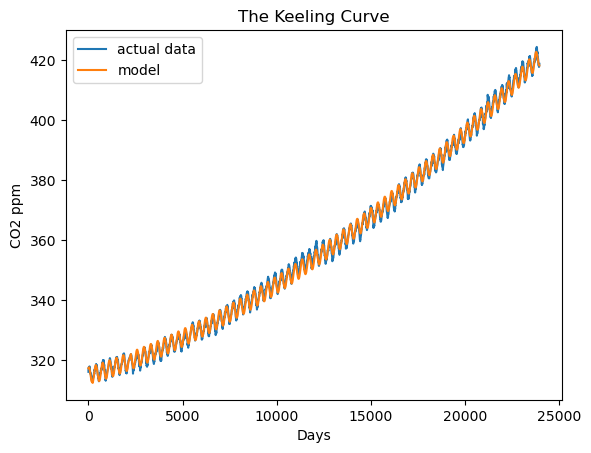

In [6]:
# Make sure we import matplotlib
import matplotlib.pyplot as plt

# Put your code here


Text(0, 0.5, 'CO2 ppm')

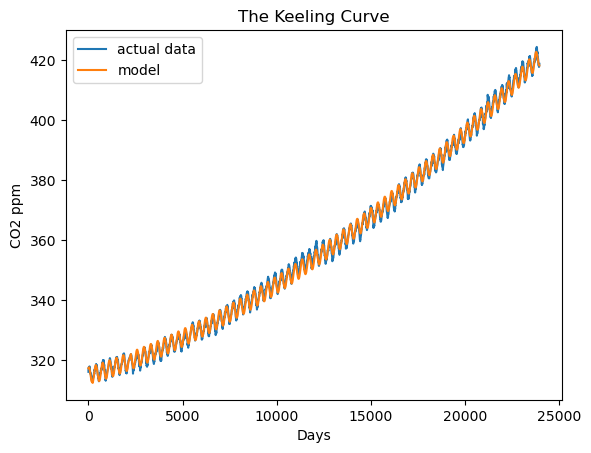

In [10]:
### ANSWER ###

plt.plot(df["days"], df["CO2ppm"], label="actual data")
plt.plot(df["days"], keeling_func(df["days"], params), label="model")
plt.legend()
plt.title("The Keeling Curve")
plt.xlabel("Days")
plt.ylabel("CO2 ppm")

# Rubric
# 5pts for plotting actual data
# 5pts for plotting modeled data
# 5pts for using a legend
# 5pts for x and y axis labels and a title

---

### Congratulations, you're done!

Submit this quiz by uploading it to the course Desire2Learn web page.  Go to the "Quizzes" section, find the submission folder link for Quiz #3, and upload it there.